In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten

In [2]:
df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
print(df.shape)

print(df['sentiment'].value_counts())

(50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [4]:
le = LabelEncoder()

df['sentiment'] = le.fit_transform(df['sentiment'])

In [5]:
x = df['review'].values

y = df['sentiment'].values

In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=42
)

In [7]:
vocab_size = 10000

max_len = 200

In [8]:
tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(x_train)

In [9]:
x_train_seq = tokenizer.texts_to_sequences(x_train)

x_test_seq = tokenizer.texts_to_sequences(x_test)

In [10]:
x_train_pad = pad_sequences(
    x_train_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

x_test_pad = pad_sequences(
    x_test_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

In [11]:
model = Sequential()

model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        input_length=max_len
    )
)

model.add(Flatten())

model.add(Dense(64, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

C:\Users\soham\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [12]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    x_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.7980 - loss: 0.4182 - val_accuracy: 0.8566 - val_loss: 0.3305
Epoch 2/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9620 - loss: 0.1087 - val_accuracy: 0.8346 - val_loss: 0.4721
Epoch 3/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9963 - loss: 0.0148 - val_accuracy: 0.8400 - val_loss: 0.6529
Epoch 4/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9994 - loss: 0.0029 - val_accuracy: 0.8397 - val_loss: 0.7218
Epoch 5/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 1.0000 - loss: 4.1030e-04 - val_accuracy: 0.8491 - val_loss: 0.7731
Epoch 6/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9973 - loss: 0.0080 - val_accuracy: 0.8114 - val_loss: 1.0670
Epoch 7/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9840 - loss: 0.0462 - val_accuracy: 0.8323 - val_loss: 0.7571
Epoch 8/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9984 - loss: 0.004

In [15]:
loss, accuracy = model.evaluate(
    x_test_pad,
    y_test
)

print("Accuracy:", accuracy)

print("Loss:", loss)

469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8374 - loss: 1.0356
Accuracy: 0.8374000191688538
Loss: 1.0356152057647705


In [16]:
y_pred_prob = model.predict(x_test_pad)

y_pred = (y_pred_prob > 0.5).astype(int)

469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [17]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[6147 1264]
 [1175 6414]]


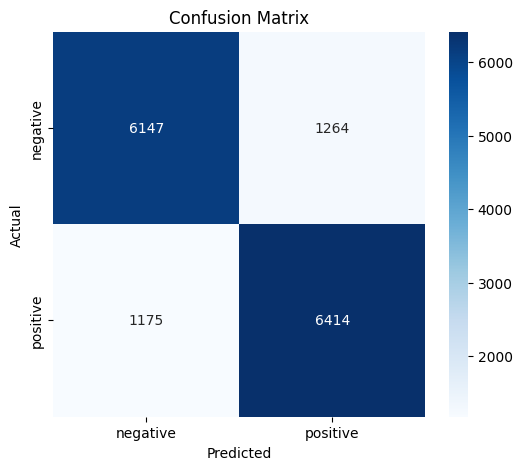

In [18]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['negative', 'positive'],
    yticklabels=['negative', 'positive']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [19]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['negative', 'positive']
))

              precision    recall  f1-score   support

    negative       0.84      0.83      0.83      7411
    positive       0.84      0.85      0.84      7589

    accuracy                           0.84     15000
   macro avg       0.84      0.84      0.84     15000
weighted avg       0.84      0.84      0.84     15000



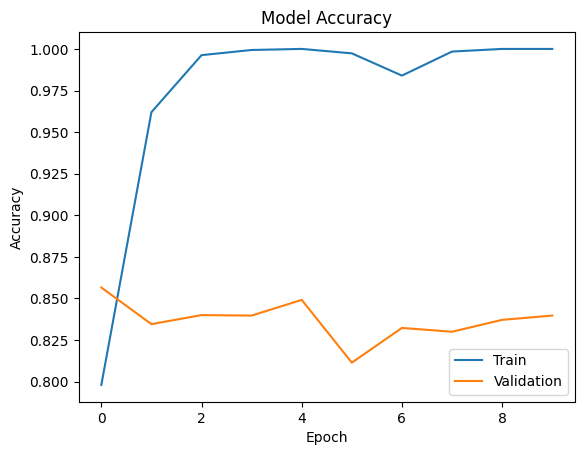

In [20]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

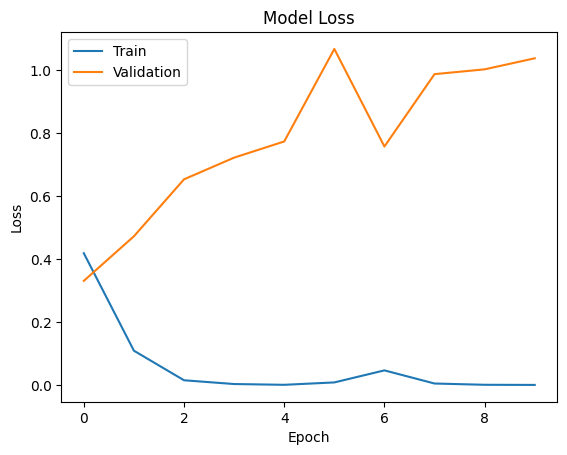

In [21]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()